Skipping Solar_Cells: file not found
Saved: ./data/results/q1_integration_metrics.csv


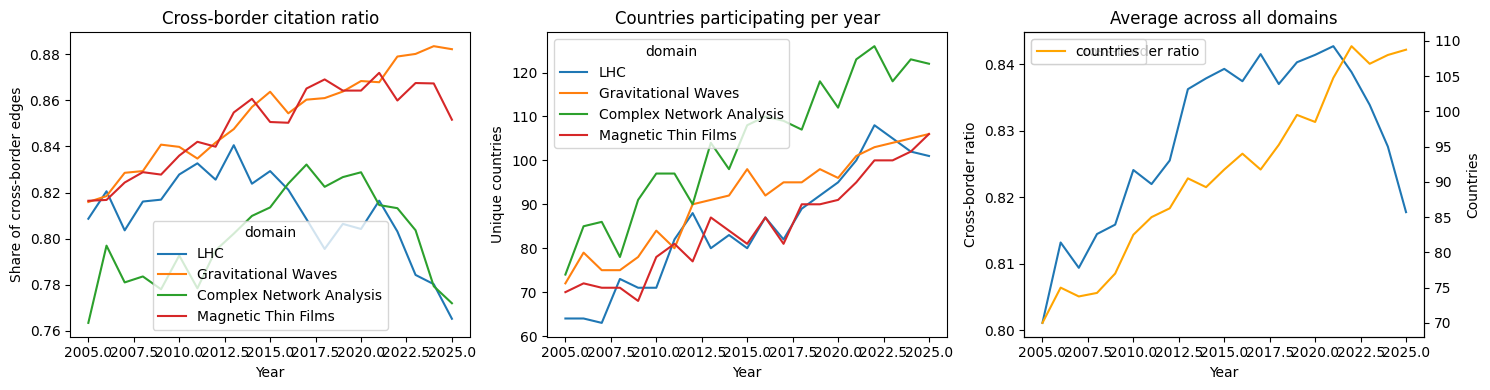

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

DATA_DIR = "./data"

DOMAINS = {
    "LHC":                      "LHC",
    "Gravitational_Waves":      "Gravitational Waves",
    "Complex_Network_Analysis": "Complex Network Analysis",
    "Magnetic_Thin_Films":      "Magnetic Thin Films",
    "Solar_Cells":              "Solar Cells",
}

def load_country_map(domain_key):
    path = os.path.join(DATA_DIR, f"geo_dict_{domain_key}.csv")
    geo = pd.read_csv(path)
    id_col = geo.columns[0]
    geo = geo.rename(columns={id_col: "inst_id"})
    return dict(zip(geo["inst_id"].astype(str), geo["country"]))

def compute_integration_metrics(domain_key):
    net_path = os.path.join(DATA_DIR, f"institution_network_evolution_{domain_key}_2005_2025.csv")
    if not os.path.exists(net_path):
        print(f"Skipping {domain_key}: file not found")
        return None
    net = pd.read_csv(net_path)
    country_map = load_country_map(domain_key)
    net["src_country"] = net["source_id"].astype(str).map(country_map)
    net["tgt_country"] = net["target_id"].astype(str).map(country_map)
    net = net.dropna(subset=["src_country", "tgt_country"])

    rows = []
    for year, grp in net.groupby("publication_year"):
        total        = len(grp)
        cross        = len(grp[grp["src_country"] != grp["tgt_country"]])
        n_countries  = len(set(grp["src_country"]) | set(grp["tgt_country"]))
        rows.append({
            "year":         int(year),
            "total_edges":  total,
            "cross_border": cross,
            "countries":    n_countries,
            "cross_ratio":  cross / total if total else 0,
        })
    return pd.DataFrame(rows).sort_values("year")

all_data = {}
for key, label in DOMAINS.items():
    df = compute_integration_metrics(key)
    if df is not None:
        all_data[label] = df

plot_df = pd.concat(
    [df.assign(domain=label) for label, df in all_data.items()],
    ignore_index=True
)

os.makedirs("./data/results", exist_ok=True)
plot_df[["domain", "year", "total_edges", "cross_border", "countries", "cross_ratio"]].to_csv(
    "./data/results/integration_metrics.csv", index=False
)

# plot
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.lineplot(data=plot_df, x="year", y="cross_ratio", hue="domain", ax=axes[0])
axes[0].set_title("Cross-border citation ratio")
axes[0].set_ylabel("Share of cross-border edges")
axes[0].set_xlabel("Year")

sns.lineplot(data=plot_df, x="year", y="countries", hue="domain", ax=axes[1])
axes[1].set_title("Countries participating per year")
axes[1].set_ylabel("Unique countries")
axes[1].set_xlabel("Year")

avg = plot_df.groupby("year")[["cross_ratio", "countries"]].mean().reset_index()
sns.lineplot(data=avg, x="year", y="cross_ratio", ax=axes[2], label="cross-border ratio")
ax2 = axes[2].twinx()
sns.lineplot(data=avg, x="year", y="countries", ax=ax2, color="orange", label="countries")
axes[2].set_title("Average across all domains")
axes[2].set_ylabel("Cross-border ratio")
axes[2].set_xlabel("Year")
ax2.set_ylabel("Countries")

plt.tight_layout()
plt.savefig("./figures/integration_analysis.png", dpi=150, bbox_inches="tight")
plt.show()